In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np

In [7]:
filename = "/content/drive/MyDrive/train.csv"
df = pd.read_csv(filename, nrows=10000)

/tmp/ipykernel_23236/3885544682.py:2: DtypeWarning: Columns (8,9,10,11,12,43,196,214,225,228,229,231,235,238) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, nrows=10000)


In [8]:
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} features.")

df.head()

The dataset has 10000 rows and 1934 features.


,ID,VAR_0001,VAR_0002,VAR_0003,VAR_0004,VAR_0005,VAR_0006,VAR_0007,VAR_0008,VAR_0009,...,VAR_1926,VAR_1927,VAR_1928,VAR_1929,VAR_1930,VAR_1931,VAR_1932,VAR_1933,VAR_1934,target
0,2,H,224,0,4300,C,0.0,0.0,False,False,...,98,98,998,999999998,998,998,9998,9998,IAPS,0
1,4,H,7,53,4448,B,1.0,0.0,False,False,...,98,98,998,999999998,998,998,9998,9998,IAPS,0
2,5,H,116,3,3464,C,0.0,0.0,False,False,...,98,98,998,999999998,998,998,9998,9998,IAPS,0
3,7,H,240,300,3200,C,0.0,0.0,False,False,...,98,98,998,999999998,998,998,9998,9998,RCC,0
4,8,R,72,261,2000,N,0.0,0.0,False,False,...,98,98,998,999999998,998,998,9998,9998,BRANCH,1


In [9]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

Numerical features: 1883
Categorical features: 51


In [10]:
imbalance = df['target'].value_counts(normalize=True) * 100
print("Percentage of each class:")
print(imbalance)

Percentage of each class:
target
0    78.01
1    21.99
Name: proportion, dtype: float64


In [11]:
total_missing = df.isnull().sum().sum()
print(f"Total missing values found: {total_missing}")

print("\nTop 5 columns with missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(5))

Total missing values found: 241084

Top 5 columns with missing values:
VAR_0207    10000
VAR_0213    10000
VAR_0840    10000
VAR_0214     9999
VAR_0157     9937
dtype: int64


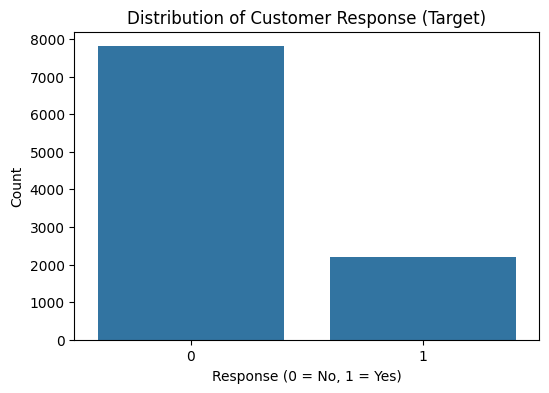

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Customer Response (Target)')
plt.xlabel('Response (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

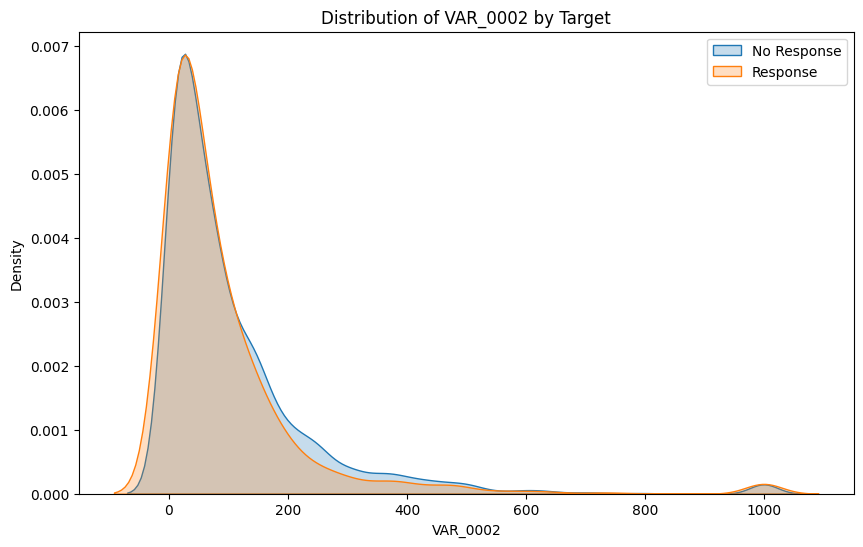

In [13]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['target'] == 0]['VAR_0002'], label='No Response', fill=True)
sns.kdeplot(df[df['target'] == 1]['VAR_0002'], label='Response', fill=True)
plt.title('Distribution of VAR_0002 by Target')
plt.legend()
plt.show()

In [14]:
cat_analysis = pd.crosstab(df['VAR_0001'], df['target'], normalize='index') * 100
print("Percentage of response per category in VAR_0001:")
print(cat_analysis)

Percentage of response per category in VAR_0001:
target            0          1
VAR_0001                      
H         81.366016  18.633984
Q         87.500000  12.500000
R         75.494964  24.505036


In [15]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

df.drop(columns=constant_cols, inplace=True)

print(f"Dropped {len(constant_cols)} constant or empty columns.")
print(f"New shape: {df.shape}")

Dropped 67 constant or empty columns.
New shape: (10000, 1867)


In [18]:
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Missing values have been dealt with.")

Missing values have been dealt with.


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical features converted to numerical labels.")

Categorical features converted to numerical labels.


In [20]:
X = df.drop(columns=['ID', 'target'])
y = df['target']

print(f"Final feature count for training: {X.shape[1]}")

Final feature count for training: 1865


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 8000
Validation samples: 2000


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [23]:
y_probs = model.predict_proba(X_val)[:, 1]

auc_score = roc_auc_score(y_val, y_probs)
print(f"Validation AUC Score: {auc_score:.4f}")

Validation AUC Score: 0.7266


In [24]:
test_filename = "/content/drive/MyDrive/test.csv"
test_df = pd.read_csv(test_filename)

test_ids = test_df['ID']
X_test = test_df[X.columns]

X_test = X_test.fillna(X.median(numeric_only=True))
X_test = X_test.fillna("Unknown")

for col in cat_cols:
    if col in X_test.columns:
        X_test[col] = le.fit_transform(X_test[col].astype(str))

test_predictions = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "ID": test_ids,
    "target": test_predictions
})

submission.to_csv("submission.csv", index=False)
print("Submission file 'submission.csv' has been created!")

/tmp/ipykernel_23236/3815924554.py:2: DtypeWarning: Columns (8,9,10,11,12,43,157,167,177,196,214,225,228,229,231,235,238) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_filename)


Submission file 'submission.csv' has been created!
